# Wstępna obróbka danych - częśc Filipa do sprawdzenia

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as py
import scipy as sp
import seaborn as sb
import sklearn as sk
import seaborn as sns 
import os


In [25]:
# Pobiera folder, w którym znajduje się ten plik .py
skrypt_dir = os.path.dirname(os.path.abspath(os.getcwd()))

# Łączy ścieżkę skryptu z podfolderem i plikiem
sciezka_pliku = os.path.join(skrypt_dir, "data", "apartments_for_rent_classified_100K.csv")

# WCZYTANIE DANYCH
df_apartments = pd.read_csv(sciezka_pliku, sep=';', encoding="cp1250")
df_apartments.head(5)

C:\Users\mhi\AppData\Local\Temp\ipykernel_31556\876345271.py:8: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df_apartments = pd.read_csv(sciezka_pliku, sep=';', encoding="cp1250")


,id,category,title,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,NaN,1.0,1.0,USD,No,Thumbnail,Cats,...,"$2,195",Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1577360355
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,NaN,1.5,3.0,USD,No,Thumbnail,"Cats,Dogs",...,"$1,250",Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1577360340
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,NaN,2.0,3.0,USD,No,Thumbnail,NaN,...,"$1,395",Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1577360332
3,5668639659,housing/rent/apartment,Two BR 209 Aegean Way,NaN,1.0,2.0,USD,No,Thumbnail,"Cats,Dogs",...,"$1,600",Monthly,820,209 Aegean Way,Vacaville,CA,38.3622,-121.9712,RentLingo,1577360330
4,5668639374,housing/rent/apartment,One BR 4805 Marquette NE,NaN,1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",...,$975,Monthly,624,4805 Marquette NE,Albuquerque,NM,35.1038,-106.6110,RentLingo,1577360308


In [26]:
df_apartments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             100000 non-null  int64  
 1   category       100000 non-null  object 
 2   title          100000 non-null  object 
 3   amenities      83909 non-null   object 
 4   bathrooms      99937 non-null   float64
 5   bedrooms       99876 non-null   float64
 6   currency       100000 non-null  object 
 7   fee            100000 non-null  object 
 8   has_photo      100000 non-null  object 
 9   pets_allowed   39256 non-null   object 
 10  price          99999 non-null   float64
 11  price_display  99999 non-null   object 
 12  price_type     100000 non-null  object 
 13  square_feet    100000 non-null  int64  
 14  address        7943 non-null    object 
 15  cityname       99698 non-null   object 
 16  state          99698 non-null   object 
 17  latitude       99975 non-null 

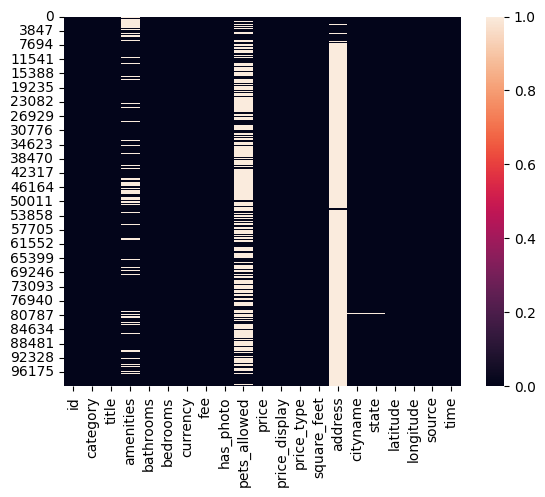

In [27]:
sns.heatmap(df_apartments.isna());

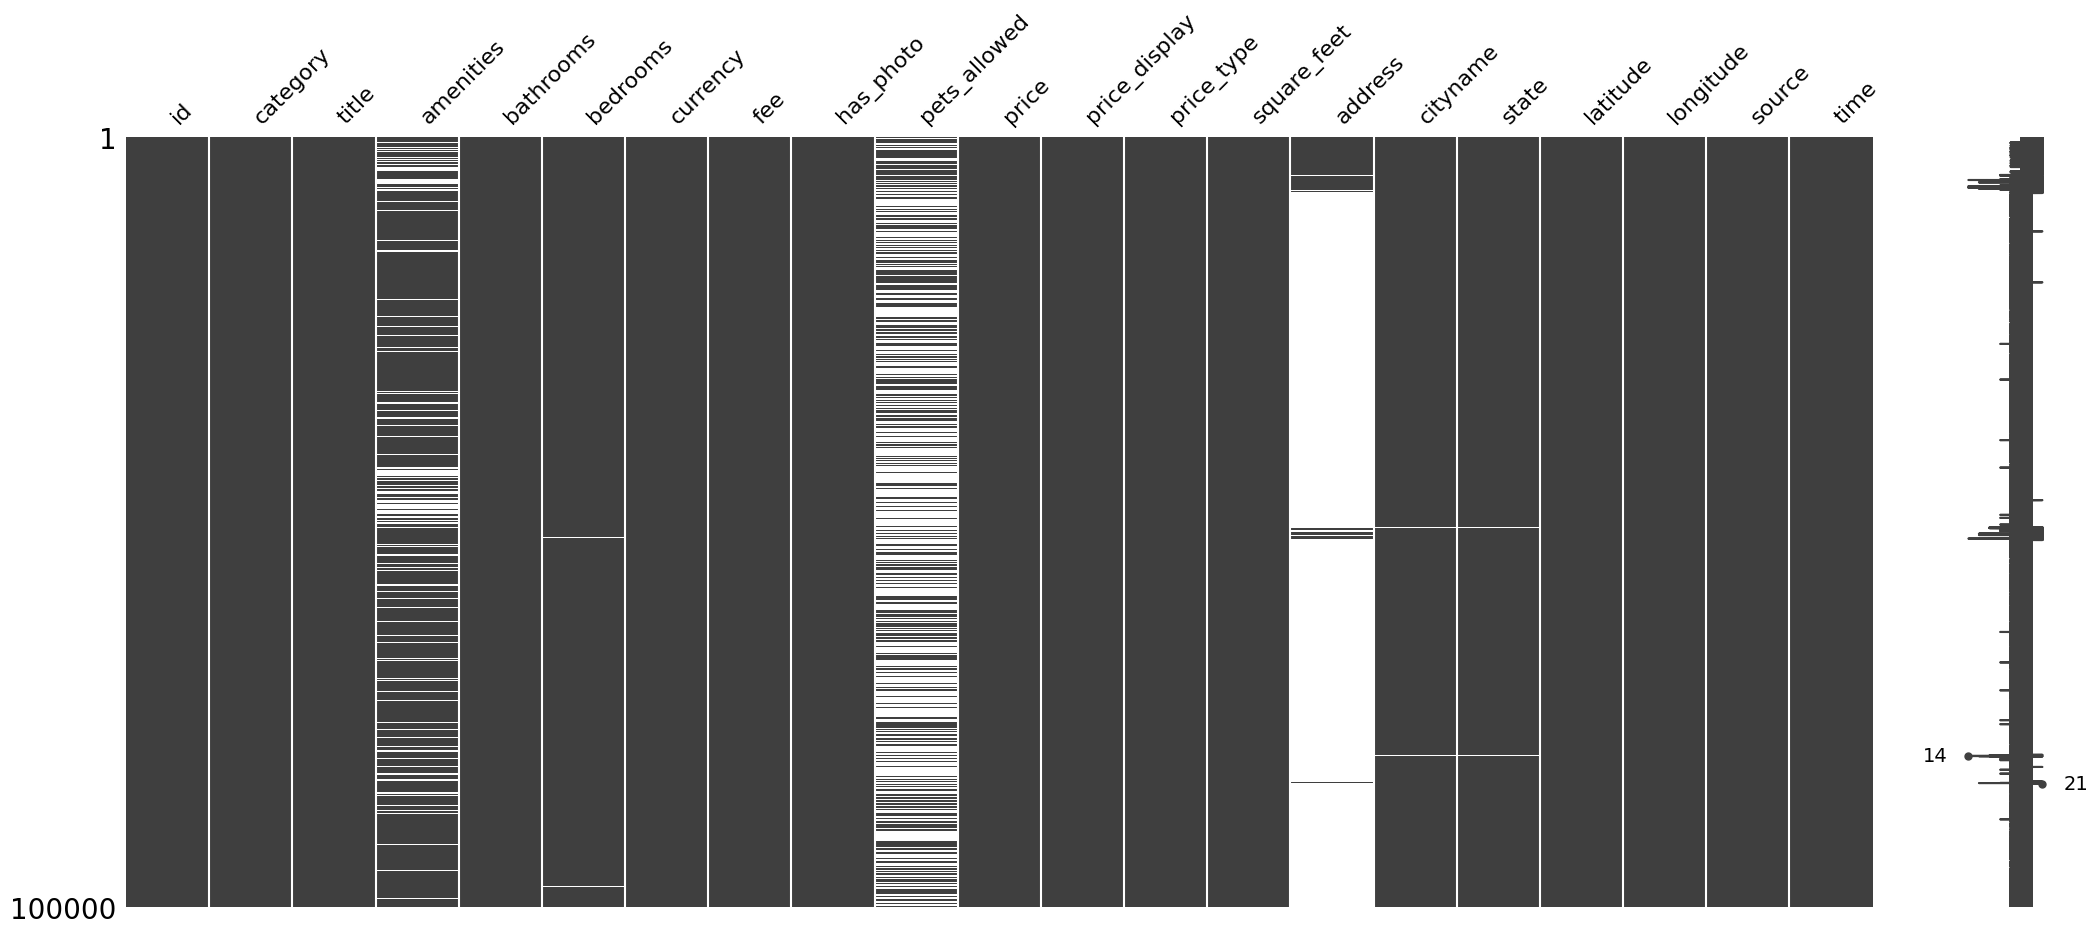

In [28]:
import missingno as msno
msno.matrix(df_apartments);

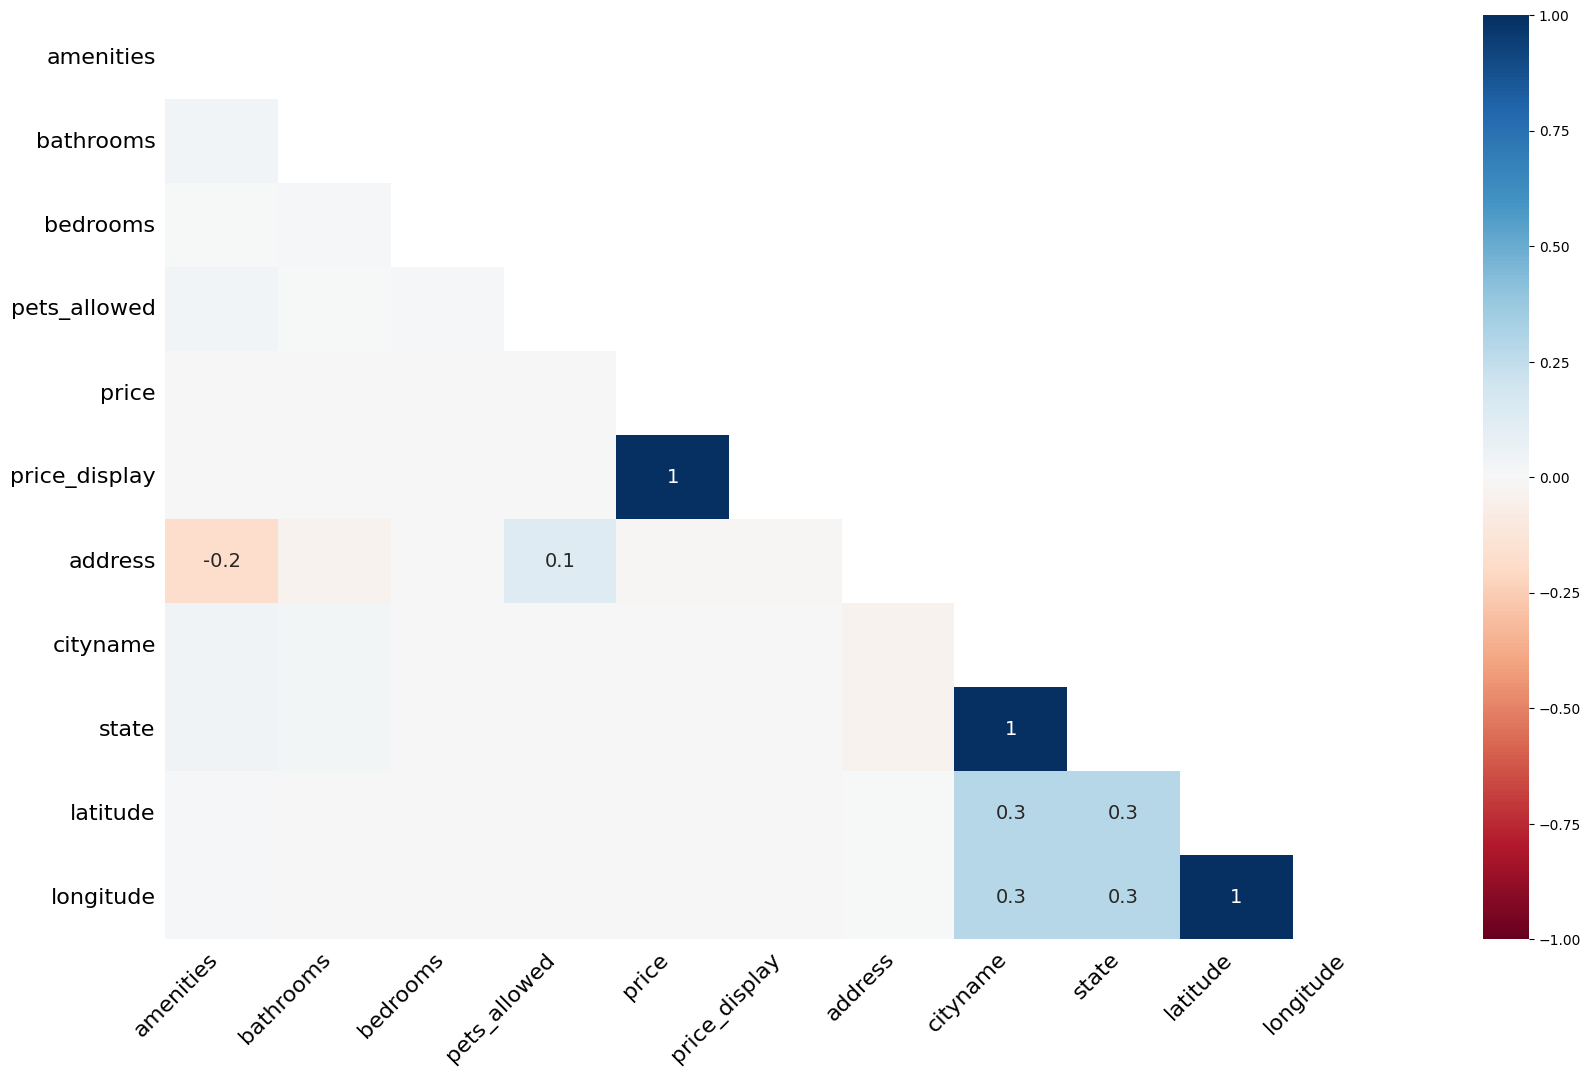

In [29]:
msno.heatmap(df_apartments);

### Krótka anliza
Widzimy, że brakujące dane są w kategoriach takich jak zwierzęta, pomieszczenia, adresy, nazwy miast, stany i współrzędne geograficzne.
Poniżej zrobiono zestawienie wyników i na ich bazie dokonano podziału na informacje do odrzucenia i ewentualnego uzupełnienia.

In [ ]:
df_apartments.isnull().sum()


id                   0
category             0
title                0
amenities        16091
bathrooms           63
bedrooms           124
currency             0
fee                  0
has_photo            0
pets_allowed     60744
price                1
price_display        1
price_type           0
square_feet          0
address          92057
cityname           302
state              302
latitude            25
longitude           25
source               0
time                 0
dtype: int64

In [ ]:
df_apartments['pets_allowed'].value_counts()

pets_allowed
Cats,Dogs         37279
Cats               1849
Dogs                127
Cats,Dogs,None        1
Name: count, dtype: int64

### Uwaga
Z tego wynika, że brak danych (NA) dla kolumny pets należy potraktować jako not allowed, duplikuje się strwierdzenie "Cats, Dogs, None" należy to zmienić na pojedynczy wpis "Cats, Dogs"

In [ ]:
# Zgodnie z powyższym dopisuję zmianę null na "None"
df_apartments["pets_allowed"] = df_apartments["pets_allowed"].fillna("None")

#zamiana pozycji jednostkowej Cats,Dogs,None na Cats,Dogs
df_apartments['pets_allowed'] = df_apartments['pets_allowed'].str.replace("Cats,Dogs,None", "Cats,Dogs", regex=False)
df_apartments['pets_allowed'].value_counts()

pets_allowed
None         60744
Cats,Dogs    37280
Cats          1849
Dogs           127
Name: count, dtype: int64

In [ ]:
# Zgodnie ze wstępną analizą w analiza.ipynb usuwamy linię bez ceny
df_apartments = df_apartments.dropna(subset=["price"])


df_najdrozsze = df_apartments[(df_apartments["price"] >= 10000) ]
df_drogie = df_apartments[(df_apartments["price"] >=5000) & (df_apartments["price"] < 10000)]
df_srednie = df_apartments[(df_apartments["price"] >=600) & (df_apartments["price"] < 5000)]
df_tanie = df_apartments[(df_apartments["price"] <600) ]


In [ ]:
df_apartments['amenities'].value_counts()

amenities
Parking                                                                                                                                       6210
Parking,Storage                                                                                                                               2119
Gym,Pool                                                                                                                                      1876
Pool                                                                                                                                          1490
Gym,Parking,Pool                                                                                                                              1195
                                                                                                                                              ... 
AC,Basketball,Cable or Satellite,Dishwasher,Gym,Internet Access,Parking,Patio/Deck,Playground,Pool,Refrigera

Tu mamy jeden wielki rozgardziasz, nie moze tak być że mamy aż 9851 pozycji występuję jako jeden ciąg znaków, tylko dlatego ze ktos coś traktuje jako udogodnienie a inny właściciel to uważa za podstawową funkcję, proponuję zrobić tak, rozbić kazdą komórkę w tej kolumnie oddzieloną przecinkiem na poszczególne udogodnienia, sprawdzić ilośc występujących udogodnień i na bazie tego i własnych odczuć zdefiniować które są rzeczywiście udogodnieniami a które nie
### Ps
okazuję się ze wszystkie udogodnienia mozna wziąc pod uwage, tylo trzeba stworzyć macierz binarną jak poniżej

In [ ]:
#tworzymy dla kazdego udogodnienia kolumne 0-1 gdzie 0 to nie wystepuje 1 wytepuje 
amenities_rozbite = df_apartments["amenities"].str.get_dummies(sep=',')
amenities_rozbite.sum()



AC                    15881
Alarm                   364
Basketball             4168
Cable or Satellite    12579
Clubhouse             19195
Dishwasher            16687
Doorman                 221
Elevator               4348
Fireplace             14986
Garbage Disposal       3899
Gated                  8687
Golf                     27
Gym                   37511
Hot Tub                4011
Internet Access       11127
Luxury                  211
Parking               44049
Patio/Deck            26650
Playground            11390
Pool                  43750
Refrigerator          14988
Storage               21731
TV                     4516
Tennis                 8542
View                   2101
Washer Dryer          26137
Wood Floors            8934
dtype: int64

In [ ]:
# 1. Połączenie oryginalnego DataFrame z nowo utworzonymi 
df_apartments = df_apartments.join(amenities_rozbite)

# Usunięcie starej, niesformatowanej kolumny tekstowej
df_apartments = df_apartments.drop(columns=['amenities'])
df_apartments.head(5)

,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Patio/Deck,Playground,Pool,Refrigerator,Storage,TV,Tennis,View,Washer Dryer,Wood Floors
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,1.0,1.0,USD,No,Thumbnail,Cats,2195.0,...,0,0,0,0,0,0,0,0,0,0
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,1.5,3.0,USD,No,Thumbnail,"Cats,Dogs",1250.0,...,0,0,0,0,0,0,0,0,0,0
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,2.0,3.0,USD,No,Thumbnail,None,1395.0,...,0,0,0,0,0,0,0,0,0,0
3,5668639659,housing/rent/apartment,Two BR 209 Aegean Way,1.0,2.0,USD,No,Thumbnail,"Cats,Dogs",1600.0,...,0,0,0,0,0,0,0,0,0,0
4,5668639374,housing/rent/apartment,One BR 4805 Marquette NE,1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",975.0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
print(df_apartments.columns.tolist())

['id', 'category', 'title', 'bathrooms', 'bedrooms', 'currency', 'fee', 'has_photo', 'pets_allowed', 'price', 'price_display', 'price_type', 'square_feet', 'address', 'cityname', 'state', 'latitude', 'longitude', 'source', 'time', 'AC', 'Alarm', 'Basketball', 'Cable or Satellite', 'Clubhouse', 'Dishwasher', 'Doorman', 'Elevator', 'Fireplace', 'Garbage Disposal', 'Gated', 'Golf', 'Gym', 'Hot Tub', 'Internet Access', 'Luxury', 'Parking', 'Patio/Deck', 'Playground', 'Pool', 'Refrigerator', 'Storage', 'TV', 'Tennis', 'View', 'Washer Dryer', 'Wood Floors']


Wyglada na to że wszystko działa macierz binarna wygląda okej  
Sprawdzamy tu zgodnosc stanow i miast bo to wazne dane do statystyki ceny

In [ ]:
# Filtrujemy wiersze, gdzie ZARÓWNO cityname JAK I state są puste
pokrycie_miast=df_apartments[df_apartments['cityname'].isnull() & df_apartments['state'].isnull()]
len(pokrycie_miast)


302

Wiemy w takim razie ze mamy 302 brakujace informacje jednoczesnie o stanie i o miescie ale mozemy sprawdzić czy nie mamy moze czasem ich polozenia geograficznego ale najpierw sprawdzmy zgodnosc szerokosci i wysokosci a raczej braku informacji o nich

In [ ]:
pokrycie_wspolrzednych=df_apartments[df_apartments['latitude'].isnull() & df_apartments['longitude'].isnull()]
len(pokrycie_wspolrzednych)

25

Mammy pełną zgodność co do braku danych czas na sprawdzenie czy mozemy wyznaczyć w pełni położenie miast za pomocą szerokości i wysokości geograficznej warunek jest taki że funkcja len musi pokazać 0 w innym wypadku nie możemy w pełni wyznaczyć nazw miast

In [ ]:
pokrycie=df_apartments[df_apartments['latitude'].isnull() & df_apartments['state'].isnull()]
len(pokrycie)

25

Mamy informacje że 25 miast ma nieznany stan i współrzędne goegraficzne wiec mamy 0 informacji o lokacji, mozna sprawdzic jeszcze adres jesli wyjdzie więcej niż 0 oznacza to że mamy dezinformację i wyniki należy odrzucić

In [ ]:
pokrycie_adresu=df_apartments[df_apartments['address'].isnull() & df_apartments['latitude'].isnull()]
len(pokrycie_adresu)

25

Mamy 25 cen nieruchomości bez żadnych informacji o lokalizacji można te pozycje usunąc,luz za pomocą geopy mozna szukac pozostałych 277 pozycji pytanie czy warto bo przy 100k rekordow to tylko 0,3% zbioru

In [ ]:
# Wyniki usuwamy, w pliku czyszczenie1_dane_geograficzne została podjęta próba wyznaczania miast ale bezskutecznie
df_apartments = df_apartments.dropna(subset=['cityname'])
df_apartments.isnull().sum()


id                        0
category                  0
title                     0
bathrooms                59
bedrooms                124
currency                  0
fee                       0
has_photo                 0
pets_allowed              0
price                     0
price_display             0
price_type                0
square_feet               0
address               91827
cityname                  0
state                     0
latitude                  0
longitude                 0
source                    0
time                      0
AC                        0
Alarm                     0
Basketball                0
Cable or Satellite        0
Clubhouse                 0
Dishwasher                0
Doorman                   0
Elevator                  0
Fireplace                 0
Garbage Disposal          0
Gated                     0
Golf                      0
Gym                       0
Hot Tub                   0
Internet Access           0
Luxury              

Tu widać ze wstepnie udało pozbyć się braków w wartościach dołączmy analize łazieniek  i sypialni  
Wyrywkowe sprawdzenie wierszy, dla których brakuje danych o łazience, pozwala na wysnucie wniosków iż, prawdopodobnie te łazienki występują.Jednakże nie ma pewności co do tego, bezpieczniejszą opcją jest usunięcie tych danych. 



In [ ]:
df_apartments = df_apartments.dropna(subset=["bathrooms"])

Sprawdzono wyrywkowo w sieci linie, dla których przypisano 0 sypialni. </BR>
Wzięto pod uwagę, ze 500 ft² , to 46,45 m² h.</BR> w ofertach widnieją pomieszczenia bez sypialni mające 700 ft². Jednak 500 ft² jest liczbą bezpieczniejszą.</BR>
Pomieszczenia te podzielono na:
- nieduże pomieszczenia <span style="color: green;">square_feet < 500</span> łączące wiele funkcji typu:</BR>
    <span style="color: green;">kącik kuchenny + sypialny + TV</span></BR>
- większe pomieszczenia <span style="color: orange;">square_feet >= 500</span>, dla których błędnie nie przypasano sypialni, mimo, że w ofercie obecnie je widać </BR>
    Takich linii jest 90. Te dane bym usunęła

Podobną zasadę 500 ft² można użyć dla 125 linii, które mają nieokreśloną ilość sypialni.    

In [ ]:
# 1. Zostawiamy tylko poprawne wiersze (metraż < 500 LUB sypialnie > 0 i nie-null)
df_apartments = df_apartments[(df_apartments["square_feet"] < 500) | (df_apartments["bedrooms"] > 0)]

# 2. Resztę braków (w małych mieszkaniach) zamieniamy na 0
df_apartments["bedrooms"] = df_apartments["bedrooms"].fillna(0)


Sprawdzmy jeszcze bledy w nazewnictwach miast i je uporzadkujmy

In [ ]:
surowe_miasta = df_apartments['cityname'].nunique()
oczyszczone_miasta = df_apartments['cityname'].str.lower().str.strip().nunique()

print(f"przed czyszczeniem: {surowe_miasta}")
print(f"po czyszczeniu: {oczyszczone_miasta}")

przed czyszczeniem: 2978
po czyszczeniu: 2978


#### Uwaga
Liczba po poprawce nie zmieniła się oznacza to że miasta w bazie danych zostały wprowadzone w jednolitym systemie, lub wczesniej poddane czyszczeniu w trakcie tworzenia zbioru danych

In [ ]:
import difflib
#skorzystamy z wcześniej zauważonego podobieństwa i pełnego pokrycia miast ze stanami (zaufamy że są wypełnione dobrze)
for stan, sub_df in df_apartments.groupby('state'):
    # Tworzymy słownik z liczbą wystąpień każdego miasta w danym stanie
    counts = sub_df['cityname'].str.strip().str.title().value_counts().to_dict()
    unikalne_miasta = sorted(counts.keys())
    
    seen = set()
    for miasto in unikalne_miasta:
        dopasowania = difflib.get_close_matches(miasto, unikalne_miasta, n=3, cutoff=0.85)
        if len(dopasowania) > 1:
            klucz = tuple(sorted(dopasowania))
            if klucz not in seen:
                seen.add(klucz)
                
                # Formatujemy podgląd: Nazwa_Miasta (ile razy występuje)
                szczegoly = [f"{m} ({counts[m]}x)" for m in dopasowania]
                print(f"[{stan}] Kontekst ilościowy: {szczegoly}")

[CA] Kontekst ilościowy: ['Corona (24x)', 'Coronado (17x)']
[CA] Kontekst ilościowy: ['Los Alamitos (7x)', 'Los Altos (2x)']
[CA] Kontekst ilościowy: ['Santa Clara (32x)', 'Santa Clarita (1x)']
[GA] Kontekst ilościowy: ['Gainesville (3x)', 'Hinesville (3x)']
[MA] Kontekst ilościowy: ['Bedford (19x)', 'Medford (18x)']
[MA] Kontekst ilościowy: ['Boston (598x)', 'Boylston (2x)']
[MA] Kontekst ilościowy: ['East Bridgewater (1x)', 'West Bridgewater (1x)']
[MA] Kontekst ilościowy: ['North Dartmouth (6x)', 'South Dartmouth (3x)']
[MA] Kontekst ilościowy: ['North Weymouth (5x)', 'South Weymouth (75x)']
[MA] Kontekst ilościowy: ['South Dartmouth (3x)', 'South Yarmouth (2x)', 'North Dartmouth (6x)']
[MA] Kontekst ilościowy: ['South Yarmouth (2x)', 'South Dartmouth (3x)']
[NH] Kontekst ilościowy: ['Campton (1x)', 'Hampton (18x)']
[NJ] Kontekst ilościowy: ['Hightstown (15x)', 'Wrightstown (1x)']
[NY] Kontekst ilościowy: ['Bedford (1x)', 'Medford (1x)']
[OH] Kontekst ilościowy: ['Broadview Heights 

Wygląda na to że nie ma błędów w nazawch miast

Udało się przebrnąć przez usuawnie braku wartości, czas na sprawdzanie wartości błędów liczbowych

In [ ]:
# Wykluczona zostaje macierz binarna z widoku, wprowadza niepotrzebny zamęt a wiemy, że jest dobrze
invisable = df_apartments.columns[20:50].tolist()
# Wykluczenie konkretnych kolumn invisable
df_apartments.drop(columns=invisable).describe()

,id,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
count,9.932600e+04,99326.000000,99326.000000,99326.000000,99326.000000,99326.000000,99326.000000,9.932600e+04
mean,5.358290e+09,1.446791,1.731732,1524.951282,955.837465,36.942110,-91.530310,1.559664e+09
std,1.844624e+08,0.547201,0.745337,883.264762,360.899473,4.602576,15.824146,1.103748e+07
min,5.121046e+09,1.000000,0.000000,100.000000,107.000000,19.573800,-159.369800,1.544174e+09
25%,5.197949e+09,1.000000,1.000000,1014.000000,730.000000,33.746200,-104.807800,1.550832e+09
50%,5.508673e+09,1.000000,2.000000,1350.000000,900.000000,37.213900,-84.539400,1.568745e+09
75%,5.509007e+09,2.000000,2.000000,1795.000000,1116.000000,39.955900,-77.576700,1.568767e+09
max,5.669439e+09,9.000000,9.000000,40000.000000,11318.000000,64.833200,-68.778800,1.577391e+09


W analizowanym zbiorze nie występują niepoprawne wartości ujemne (z wyjątkiem współrzędnych geograficznych, gdzie są one naturalne). Widoczne są jednak bardzo wysokie wartości maksymalne oraz nielogiczne wartości minimane, szczególnie dla ceny oraz powierzchni, co sugeruje obecność silnych wartości odstających lub błędów grubych. W celu ich dokładnej identyfikacji i oceny dystrybucji danych względem centrum rozkładu (mediany) zastosowano wykresy pudełkowe (boxplots). Opierają się one na statystyce pozycyjnej (kwartylach i rozstępie międzykwartylowym), co pozwala na jednoznaczne wskazanie obserwacji odstających poza wąsami wykresu, niezależnie od skali i asymetrii rozkładu.

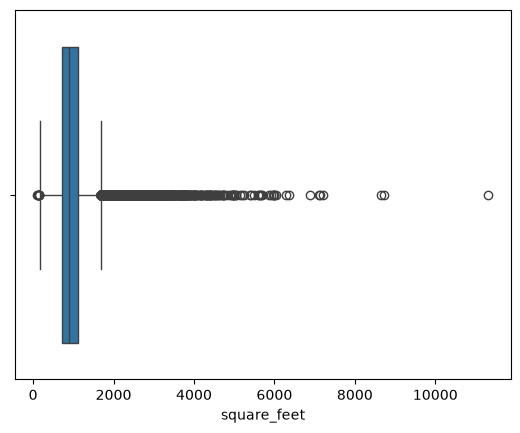

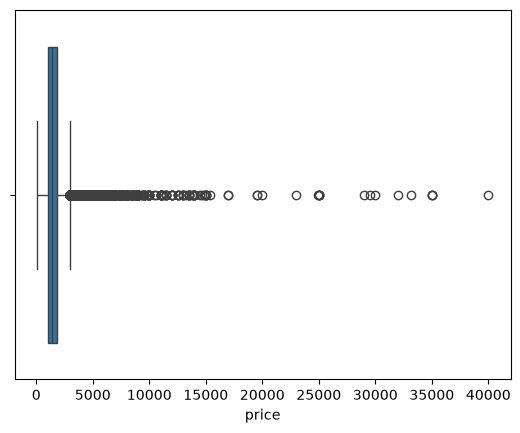

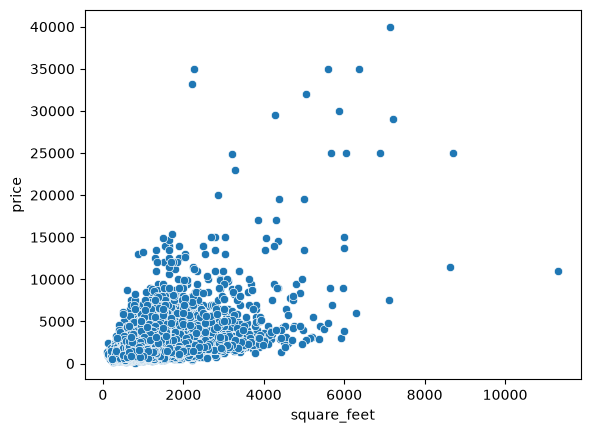

In [ ]:

# Wykres dla ceny i metrażu
sb.boxplot(x=df_apartments['square_feet'])
py.show()
sb.boxplot(x=df_apartments['price'])
py.show()

# Wykres pokazujący relację ceny do metrażu
sb.scatterplot(x=df_apartments['square_feet'], y=df_apartments['price'])
py.show()

Na wykresach widać małe anomalnie, to te obszary najbardziej odległe od punktu zero osi sprawdzmy to jednak jeszcze w odniesieniu o pare innych zmiennych badz też te bardzo bliskie 0

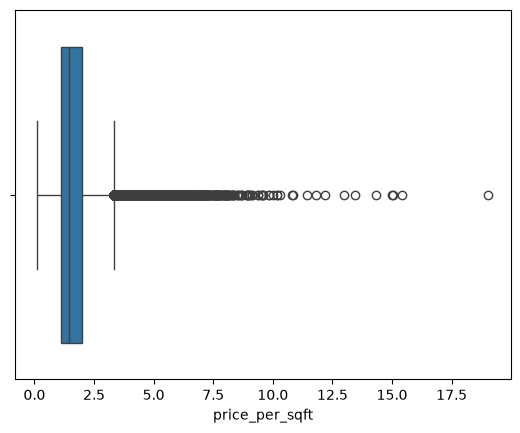

In [ ]:
df_apartments['price_per_sqft'] = df_apartments['price'] / df_apartments['square_feet']
sb.boxplot(x=df_apartments['price_per_sqft'])
py.show()

Tutaj juz troche lepiej to wygląda jednak podejrzany wydaje się skrajny element na wykresie przyjżyjmy się 10 najblizszym anomaliom 

In [ ]:
df_apartments['price'] 
df_apartments.sort_values(by='price', ascending=False).head(10)


,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Playground,Pool,Refrigerator,Storage,TV,Tennis,View,Washer Dryer,Wood Floors,price_per_sqft
41358,5508880122,housing/rent/apartment,"Average Rent $40,000 a month - That's a STEAL!",8.0,6.0,USD,No,Yes,None,40000.0,...,0,1,0,0,0,1,0,0,0,5.598321
28170,5508903100,housing/rent/apartment,Pet Friendly 6+5 Apartment in West Hollywood,5.0,7.0,USD,No,No,None,35000.0,...,0,1,1,0,0,0,0,0,0,6.265664
41141,5508903015,housing/rent/apartment,"Stunning estate in the heart of /Sunset, just ...",7.5,6.0,USD,No,No,None,35000.0,...,0,1,0,0,0,0,0,0,0,5.497958
17206,5508899537,housing/rent/apartment,Four BR - ready to move in.,4.0,4.0,USD,No,Thumbnail,None,35000.0,...,0,0,0,0,0,0,0,0,0,15.425297
46243,5508991189,housing/rent/apartment,Apartment in great location. 2 Car Garage!,2.5,3.0,USD,No,Yes,None,33165.0,...,0,0,0,0,0,0,0,0,0,15.000000
38899,5508885857,housing/rent/apartment,"Average Rent $32,000 a month - That's a STEAL....",9.0,6.0,USD,No,Yes,None,32000.0,...,0,0,0,0,1,0,0,0,0,6.330366
14475,5509150943,housing/rent/apartment,This mountain contemporary is truly one of a k...,5.5,5.0,USD,No,Thumbnail,None,30000.0,...,0,0,0,0,0,0,1,1,0,5.108992
31412,5509006958,housing/rent/apartment,Three BR Apartment - Located in the heart of o...,3.0,3.0,USD,No,Yes,None,29500.0,...,0,0,0,0,0,0,1,0,0,6.874854
38802,5508917546,housing/rent/apartment,Sensational Tuscan Villa nestled in a cul-de-s...,6.0,6.0,USD,No,Yes,None,29000.0,...,0,1,0,0,0,0,1,0,0,4.020519
3487,5668640983,housing/rent/apartment,Six BR 256 Las Entradas,8.0,6.0,USD,No,Thumbnail,None,25000.0,...,0,0,0,0,0,0,0,0,0,2.868288


In [ ]:
df_apartments['square_feet'] 

df_apartments.sort_values(by='square_feet', ascending=False).head(10)

,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Playground,Pool,Refrigerator,Storage,TV,Tennis,View,Washer Dryer,Wood Floors,price_per_sqft
3907,5668643292,housing/rent/apartment,Six BR 9908 Bentcross Drive,8.5,6.0,USD,No,Thumbnail,None,11000.0,...,0,0,0,0,0,0,0,0,0,0.971903
3487,5668640983,housing/rent/apartment,Six BR 256 Las Entradas,8.0,6.0,USD,No,Thumbnail,None,25000.0,...,0,0,0,0,0,0,0,0,0,2.868288
96260,5121433095,housing/rent/apartment,Bedford - superb Apartment nearby fine dining,6.0,5.0,USD,No,Yes,None,11500.0,...,0,0,0,0,0,0,0,0,0,1.330557
38802,5508917546,housing/rent/apartment,Sensational Tuscan Villa nestled in a cul-de-s...,6.0,6.0,USD,No,Yes,None,29000.0,...,0,1,0,0,0,0,1,0,0,4.020519
41358,5508880122,housing/rent/apartment,"Average Rent $40,000 a month - That's a STEAL!",8.0,6.0,USD,No,Yes,None,40000.0,...,0,1,0,0,0,1,0,0,0,5.598321
79786,5197893701,housing/rent/apartment,Five BR Apartment - A model of grace & elegance.,5.5,5.0,USD,No,No,None,7500.0,...,0,0,0,0,0,0,0,0,0,1.055743
23678,5509021087,housing/rent/apartment,Four BR Apartment - Beautiful bluff top proper...,5.0,4.0,USD,No,Thumbnail,None,25000.0,...,0,0,0,0,0,0,0,0,0,3.633193
41141,5508903015,housing/rent/apartment,"Stunning estate in the heart of /Sunset, just ...",7.5,6.0,USD,No,No,None,35000.0,...,0,1,0,0,0,0,0,0,0,5.497958
7126,5630240092,housing/rent/apartment,Five BR 5407 Abbott Place - Abbott,4.0,5.0,USD,No,Thumbnail,None,6000.0,...,0,0,0,0,0,0,0,0,0,0.952381
41625,5508857852,housing/rent/apartment,"Bright Los Angeles, Five BR, Six BA for rent. ...",7.0,5.0,USD,No,Yes,None,25000.0,...,0,1,0,0,0,0,0,0,0,4.142502


In [ ]:
df_apartments['price_per_sqft'] = df_apartments['price'] / df_apartments['square_feet']

df_apartments.sort_values(by='price_per_sqft', ascending=False).head(10)


,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Playground,Pool,Refrigerator,Storage,TV,Tennis,View,Washer Dryer,Wood Floors,price_per_sqft
7148,5667891676,housing/rent/apartment,0 BR in New York NY 10019,1.0,0.0,USD,No,Thumbnail,None,2475.0,...,0,1,0,1,0,0,0,0,0,19.038462
17206,5508899537,housing/rent/apartment,Four BR - ready to move in.,4.0,4.0,USD,No,Thumbnail,None,35000.0,...,0,0,0,0,0,0,0,0,0,15.425297
37395,5508850926,housing/rent/apartment,Contemporary Executive Residence in wood.,2.0,2.0,USD,No,Yes,None,12995.0,...,0,0,0,0,0,0,0,0,0,15.023121
46243,5508991189,housing/rent/apartment,Apartment in great location. 2 Car Garage!,2.5,3.0,USD,No,Yes,None,33165.0,...,0,0,0,0,0,0,0,0,0,15.000000
45730,5508899890,housing/rent/apartment,Studio - heart of the Sunset Strip. Will Consi...,1.0,2.0,USD,No,Thumbnail,None,8700.0,...,0,1,0,0,0,0,0,0,0,14.332784
88550,5121223336,housing/rent/apartment,Apartment for rent in New York.,2.5,4.0,USD,No,Yes,None,13278.0,...,0,0,0,0,0,0,0,0,1,13.439271
4998,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...",1.0,0.0,USD,No,Thumbnail,None,1390.0,...,0,0,0,0,0,0,0,0,0,12.990654
97321,5121374579,housing/rent/apartment,Two BR Apartment - Located in Downtown tan s m...,2.0,2.0,USD,No,Yes,None,6100.0,...,0,0,0,0,0,0,0,0,0,12.200000
97322,5121374247,housing/rent/apartment,Two BR Apartment - Located in Downtown tan s m...,2.0,2.0,USD,No,Yes,None,5900.0,...,0,0,0,0,0,0,0,0,0,11.800000
89783,5121712250,housing/rent/apartment,Now offering 2 year lease with no increase!,2.0,2.0,USD,No,Yes,None,4611.0,...,0,0,0,0,1,0,0,0,1,11.441687


In [ ]:
with pd.option_context('display.max_columns', None, 'display.expand_frame_repr', False):
    print(df_apartments[df_apartments['id'] == 5667891676])

              id                category                      title  bathrooms  bedrooms currency fee  has_photo pets_allowed   price price_display price_type  square_feet           address   cityname state  latitude  longitude    source        time  AC  Alarm  Basketball  Cable or Satellite  Clubhouse  Dishwasher  Doorman  Elevator  Fireplace  Garbage Disposal  Gated  Golf  Gym  Hot Tub  Internet Access  Luxury  Parking  Patio/Deck  Playground  Pool  Refrigerator  Storage  TV  Tennis  View  Washer Dryer  Wood Floors  price_per_sqft
7148  5667891676  housing/rent/apartment  0 BR in New York NY 10019        1.0       0.0      USD  No  Thumbnail         None  2475.0        $2,475    Monthly          130  350 West 50th St  Manhattan    NY   40.7629   -73.9885  Listanza  1577289784   0      0           0                   0          0           1        0         1          0                 0      0     0    0        0                0       0        0           1           0     1       

In [ ]:
with pd.option_context('display.max_columns', None, 'display.expand_frame_repr', False):
    print(df_apartments[df_apartments['id'] == 5668626833])

              id                category                                              title  bathrooms  bedrooms currency fee  has_photo pets_allowed   price price_display price_type  square_feet address   cityname state  latitude  longitude     source        time  AC  Alarm  Basketball  Cable or Satellite  Clubhouse  Dishwasher  Doorman  Elevator  Fireplace  Garbage Disposal  Gated  Golf  Gym  Hot Tub  Internet Access  Luxury  Parking  Patio/Deck  Playground  Pool  Refrigerator  Storage  TV  Tennis  View  Washer Dryer  Wood Floors  price_per_sqft
4998  5668626833  housing/rent/apartment  Studio apartment N Scott St, 14th St N, Arling...        1.0       0.0      USD  No  Thumbnail         None  1390.0        $1,390    Monthly          107     NaN  Arlington    VA    38.891   -77.0816  RentLingo  1577359410   0      0           0                   0          0           0        0         0          0                 0      0     0    0        0                0       0        0       

#### Uwaga
Większość z lokali nosi znamiona wielopokojowych, dobrze wyposażonych bądź luksusowych, dwa nie wpisujące się w te ramy zostały poddane analizie, oba bronią się swoją lokalizacją, centrum nowego jorku na manhatanie, drugi z kolei znajduje się tuż nad rzeką Potomak, naprzeciwko Georgetown i kluczowych dzielnic rządowych oraz biznesowych Waszyngtonu.  
Informacje o błędzie można stanowczo odrzucić patrząc na lokalizacje lokali, cena wydaje się adekwatna, jeśli problem ceny został rozwiązany czas przyjrzeć się wykresowi sqft gdzie widać wartość 0. Jednakże w zbiorze segregowanych ceną znalazły się dwa wystąpienia nielogiczne o tytułach zawierających "That's a steal" należy je usunąć i sprawdzić występowanie w innych grupach. Należy sprawdzić czy nie ma ich więcej.

In [ ]:
ilosc_zartow = df_apartments['title'].str.contains(r'\baverage\b', case=False, na=False)
print(f"Liczba ogłoszeń z 'Average' w tytule: {ilosc_zartow.sum()}")
zarty = df_apartments[ilosc_zartow]
zarty[['id', 'title', 'price']].head(10)



Liczba ogłoszeń z 'Average' w tytule: 1663


,id,title,price
7359,5509148143,"Average Rent $1,289 a month - That's a STEAL. ...",1289.0
7368,5509113870,"Average Rent $2,155 a month - That's a STEAL. ...",2155.0
7533,5509211431,Average Rent $805 a month - That's a STEAL. Si...,805.0
7536,5509179979,"Average Rent $2,101 a month - That's a STEAL. ...",2101.0
7590,5509041005,"Average Rent $2,055 a month - That's a STEAL. ...",2055.0
7670,5508793264,"Average Rent $1,832 a month - That's a STEAL!",1832.0
7675,5508761131,"Average Rent $1,565 a month - That's a STEAL. ...",1565.0
7740,5509260352,Average Rent $675 a month - That's a STEAL!,675.0
7763,5509237189,"Average Rent $1,735 a month - That's a STEAL. ...",1735.0
7859,5509011092,"Average Rent $3,135 a month - That's a STEAL. ...",3135.0


Mamy w tym miejscu do czynienia ze zwlosliwym zatruciem danych ale mozna w latwy sposob się go pozbyć, jesli wystąpiło w takiej formie jednorazowo.

In [ ]:

zarty_do_usuniecia_1 = df_apartments['title'].str.contains(r'\baverage\b', case=False, na=False)
df_apartments = df_apartments[~zarty_do_usuniecia_1]


Skoro udało się pozbyć jednego problemu to trzeba sprawdzić czy nie wytępują inne, sprawdzalismy biegun najwyzszej ceny czas na ten najniższej oraz na sprawdzenie spamu.  Poniżej można zauważyć pewne nieprawidłowości, lokacje z ponadnomatywną ilością sypialni za bardzo niską cene, należy przejrzeć ceny za sqft rosnocą od najniższej

In [ ]:
#sprawdzenie wartości minimalnych
df_apartments['price'] 
df_apartments.sort_values(by='price', ascending=True).head(10)

,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Playground,Pool,Refrigerator,Storage,TV,Tennis,View,Washer Dryer,Wood Floors,price_per_sqft
52249,5570188951,housing/rent/apartment,Park Management LLC,1.0,2.0,USD,Yes,Thumbnail,None,100.0,...,0,0,1,0,0,0,0,0,1,0.125000
6286,5664571561,housing/rent/apartment,One BR Ridge Road,1.0,1.0,USD,No,Thumbnail,None,200.0,...,0,0,0,0,0,0,0,0,0,0.800000
4417,5668626546,housing/rent/apartment,Studio apartment 116 N 2nd St,1.0,1.0,USD,No,Thumbnail,None,224.0,...,0,0,0,0,0,0,0,0,0,0.381601
22973,5508727124,housing/rent/apartment,Come home to Auburn Trace Apartments. $264/mo,1.0,1.0,USD,No,Yes,None,264.0,...,1,0,0,0,0,0,0,1,0,0.352000
84243,5121995967,housing/rent/apartment,Apartment for rent in Talladega. Pet OK!,1.0,1.0,USD,No,Yes,"Cats,Dogs",285.0,...,0,0,1,0,1,0,0,0,0,0.712500
3769,5668617931,housing/rent/apartment,One BR 1200 Mallard Drive,1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",288.0,...,1,0,1,0,0,0,0,0,0,0.375979
53014,5198522226,housing/rent/apartment,Columbus - 1bd/One BA 736sqft Apartment for re...,1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",299.0,...,0,0,1,0,0,0,0,1,0,0.406250
52016,5648710683,housing/rent/apartment,Delmain Apartments,1.0,0.0,USD,Yes,Thumbnail,None,300.0,...,0,0,1,0,0,0,0,0,0,1.224490
4562,5668620544,housing/rent/apartment,Studio apartment 4440 Gulfway Dr,1.0,2.0,USD,No,Thumbnail,None,300.0,...,0,0,1,0,0,0,0,0,0,0.750000
12649,5509036351,housing/rent/apartment,MODERN LUXURIOUS LIVING. $309/mo,1.0,1.0,USD,No,Thumbnail,None,309.0,...,0,1,0,1,0,0,0,1,0,0.411451


#### Uwaga
Prawdopodbny scam lub źle wpisana wartość lub wartość przedpłaty, posortowanie danych według ceny za sqft przyniosło skutek i obnazyło zadzwiająco niskie ceny za sqft. Proponowanym rozwiązaniem jest zastosowanie percentyli do segregacji danych

In [ ]:
df_apartments['price_per_sqft'] = df_apartments['price'] / df_apartments['square_feet']

df_apartments.sort_values(by='price_per_sqft', ascending=True).head(5)

,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Playground,Pool,Refrigerator,Storage,TV,Tennis,View,Washer Dryer,Wood Floors,price_per_sqft
52249,5570188951,housing/rent/apartment,Park Management LLC,1.0,2.0,USD,Yes,Thumbnail,None,100.0,...,0,0,1,0,0,0,0,0,1,0.125000
2816,5668616581,housing/rent/apartment,Four BR 11 Maverick Dr,3.0,4.0,USD,No,Thumbnail,"Cats,Dogs",430.0,...,0,1,1,0,1,0,0,0,0,0.194219
43915,5508988204,housing/rent/apartment,"Attractive Three BR, One BA",1.0,3.0,USD,No,Yes,None,500.0,...,0,0,0,0,0,0,0,0,0,0.263158
52343,5199144676,housing/rent/apartment,Excellent Apartment for Sublet!!,1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",382.0,...,0,1,0,0,0,1,0,1,0,0.264910
19412,5509099464,housing/rent/apartment,This Apartment is a must see. Washer/Dryer Hoo...,2.0,3.0,USD,No,Thumbnail,None,750.0,...,0,0,0,1,0,0,0,1,1,0.266714


In [ ]:
# 1. Wyznaczenie granic 
dolny_prog = df_apartments['price_per_sqft'].quantile(0.01)  
gorny_prog = 20 

# 2. Zastosowanie warunku
df_apartments = df_apartments[
    (df_apartments['price_per_sqft'] >= dolny_prog) & 
    (df_apartments['price_per_sqft'] <= gorny_prog)
]

# 3. Sprawdzenie
print(f"Sensowny zakres cenowy za sqft: od {dolny_prog:.2f}$ do {gorny_prog:.2f}$")



Sensowny zakres cenowy za sqft: od 0.63$ do 20.00$


In [ ]:
df_apartments.sort_values(by='price_per_sqft', ascending=True).head(5)

,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Playground,Pool,Refrigerator,Storage,TV,Tennis,View,Washer Dryer,Wood Floors,price_per_sqft
51179,5432644284,housing/rent/apartment,Discover the difference of Summertree. $757/mo,2.0,2.0,USD,No,Thumbnail,None,757.0,...,1,1,0,0,0,0,0,0,0,0.625620
56662,5198425537,housing/rent/apartment,$610/mo - must see to believe.,1.0,2.0,USD,No,Thumbnail,None,610.0,...,0,0,0,0,0,0,0,0,1,0.625641
69223,5198424751,housing/rent/apartment,The Best of the Best in the City of Newport Ne...,1.0,2.0,USD,No,Thumbnail,None,610.0,...,0,0,0,0,0,0,0,0,1,0.625641
76446,5197811293,housing/rent/apartment,Prominence Apartments Three BR Luxury Apartmen...,2.0,3.0,USD,No,Yes,"Cats,Dogs",910.0,...,0,0,0,0,0,0,0,0,0,0.626290
65879,5198320257,housing/rent/apartment,"2nd Floor Two BR, One BA apartment home locate...",1.0,2.0,USD,No,Thumbnail,"Cats,Dogs",595.0,...,0,0,0,0,0,0,0,0,0,0.626316


Dla pewności wyników i analiz sprawdzamy też drugą strone medalu wartości maksymalne które zostały odrzucone, dane jakie zostały pokazane przy percentylu 0,9 są zbyt okrojone, utraciliśmy znaczną część posiadłości luksusowych, wartość należy ustawić na stała np na poziomie najdroższego apartamentu lub pozostawić górną granice otwartą. 

In [ ]:
# Wyświetlenie próby rekordów, które zostały odcięte jako "zbyt drogie" za sqft
anomalie_gorne = df_apartments[df_apartments['price_per_sqft'] > gorny_prog]
anomalie_gorne.sort_values(by='price_per_sqft', ascending=False)[['title', 'price', 'square_feet', 'price_per_sqft', 'cityname']].head(10)

,title,price,square_feet,price_per_sqft,cityname


Kolejnym etapem jest sprawdzenie kolumn nie tak bardzo kluczowych ale jednak wystepujacych i mogących miec zanczenie są to kolumny "price_type, currency, fee"

In [ ]:
# Sprawdzenie typów płatności 
print(df_apartments['price_type'].value_counts())

# Sprawdzenie unikalnych walut 
print(df_apartments['currency'].value_counts())

# Sprawdzenie prowizji (fee)
print(df_apartments['fee'].value_counts())

price_type
Monthly    96684
Weekly         2
Name: count, dtype: int64
currency
USD    96686
Name: count, dtype: int64
fee
No     96495
Yes      191
Name: count, dtype: int64


Dla prostoty analizy posłużymy się tylko ofertami bez prowizji i z płatnościami wyłącznie co miesiąc

In [ ]:
# Zostawiamy tylko te rekordy, które mają typ ceny "Monthly" i ofertę no Fee
df_apartments = df_apartments[(df_apartments['price_type'] == 'Monthly') & (df_apartments['fee'] == 'No')]


W powyższej tabeli widzimy że pojawia się w kolumnie has_photo wartość "thumbnail" przyżyjmy się jej

In [ ]:
thumbnail_count = (df_apartments['has_photo'] ).value_counts()
print(f"Liczba 'Thumbnail': {thumbnail_count}")

Liczba 'Thumbnail': has_photo
Yes          54395
Thumbnail    33148
No            8950
Name: count, dtype: int64


Widać tu że thumbnail występuję dość często, nie może być to bład, trzeba sprawdzić nomenklaturę. Po sprawdzeniu okazuję się, że to miniaturowe zdjęcie taka mała etykieta. Dla ułatwienia analizy zmienimy thumbnail na yes

In [ ]:
df_apartments['has_photo'] = df_apartments['has_photo'].replace({'Thumbnail': 'Yes'})

Ostatnim etapem jest sprawdzenie kategorii wynajmy czy aby napewno się zgadzają oraz sprawdzenie pod kątem występowania duplikatów

In [ ]:
# Sprawdzenie kategorii
print(df_apartments['category'].value_counts())

# Zostawiamy wyłącznie apartamenty
df_apartments = df_apartments [df_apartments['category'] == 'housing/rent/apartment' ]
# Usuwamy duplikaty
df_apartments = df_apartments.drop_duplicates(subset=['title', 'price', 'square_feet', 'cityname', 'state'], keep='first')

category
housing/rent/apartment            96436
housing/rent/commercial/retail       42
housing/rent                          6
housing/rent/home                     4
housing/rent/short_term               2
housing/rent/condo                    2
housing/rent/other                    1
Name: count, dtype: int64


In [ ]:
 apartments_clean = df_apartments
 apartments_clean.to_csv('data/apartments_clean.csv', sep=';', index=False, encoding='utf-8')